<div style="padding:28px 30px;border-radius:18px;background:linear-gradient(135deg,#082f49,#075985);color:white">
  <div style="font-size:14px;letter-spacing:1px;opacity:.9">PESTA DATA NASIONAL (PeDaS) 2026 · WORKSHOP III</div>
  <h1 style="margin:8px 0 4px;font-size:34px">Trust the Data?</h1>
  <div style="font-size:20px">Dari Raw Cyber Data Menuju Insight yang Dapat Dipercaya</div>
  <div style="margin-top:18px;font-size:14px">Taufik Edy Sutanto, M.Sc. Tech., Ph.D. · 12 September 2026 · 13.00–15.00 WIB</div>
</div>

> **Pertanyaan utama:** Sebelum membuat model, apakah kita sudah benar-benar memahami apa yang direpresentasikan oleh data?

Notebook ini memakai dua sampel data PeDaS 2026:

1. `WSdata-idadx.phishes_10000_masked.csv` — Sampel Workshop data (imitasi) IDADX yang telah dimasking.
2. `WSdata-sample-dns-30min.csv` — Sampel Workshop data (imitasi) rekaman query dan response DNS.

Bahasa pemrograman: **Python** · Lingkungan: **Jupyter Notebook / Google Colab**

## Tujuan belajar

Setelah sesi ini, peserta diharapkan mampu:

- menjelaskan **unit observasi** dan konteks sebuah dataset;
- melakukan audit awal atas tipe data, missing value, keunikan, duplikasi, dan konsistensi kategori;
- membedakan **temuan**, **dugaan**, dan **hal yang perlu dikonfirmasi**;
- melakukan EDA sebagai proses investigasi, bukan sekadar membuat grafik;
- mengenali risiko awal **data leakage** sebelum memilih model;
- menyusun catatan *data readiness* yang dapat dipertanggungjawabkan.

> **Batas sesi:** Hari ini kita sengaja belum membangun model. Sesi berikutnya akan membahas validasi dan model yang mampu melakukan generalisasi.

## Alur sesi (120 menit)

| Waktu | Aktivitas | Hasil yang diharapkan |
|---:|---|---|
| 0–10 menit | Pemantik: *What do you trust?* | Peserta mempertanyakan data sebelum algoritma |
| 10–25 menit | Memuat data dan memahami grain | Hipotesis unit observasi untuk IDADX dan DNS |
| 25–50 menit | Audit kualitas data | Daftar missing, konstanta, kategori tidak konsisten, dan duplikasi |
| 50–75 menit | Investigasi IDADX | Pertanyaan EDA dan pola awal berbasis data |
| 75–95 menit | Investigasi DNS | Query–response, qtype, rcode, ukuran paket, dan normalisasi nama |
| 95–110 menit | Jebakan pertama: leakage | Kandidat feature/target/metadata/leakage |
| 110–120 menit | Mini-challenge dan refleksi | Tiga alasan mengapa kita belum boleh terburu-buru membuat model |

**Pola interaksi:** prediksi dahulu → jalankan kode → baca output → diskusikan maknanya.

## 0. Pemantik — Apa yang Anda lakukan pertama kali?

Bayangkan penyelenggara lomba memberikan sebuah file CSV atau Excel. Pilih respons yang paling dekat dengan kebiasaan Anda:

1. Langsung memilih Random Forest/XGBoost.
2. Melihat `head()`, lalu segera preprocessing.
3. Menanyakan: **apa arti satu baris, bagaimana data dikumpulkan, dan kapan setiap variabel tersedia?**
4. Melihat skor peserta lain di leaderboard.

<details>
<summary><b>Klik setelah peserta menjawab</b></summary>

Pilihan 3 adalah titik awal yang paling aman. Algoritma belum bermakna sebelum kita memahami **grain**, proses pembentukan data, dan tujuan prediksi.

**Wrong question:** “Algoritma apa yang paling akurat?”  
**Better question:** “Apa sebenarnya yang direpresentasikan oleh satu baris?”
</details>

## 1. Etika dan batas interpretasi

Data keamanan digital bukan sekadar tabel. Selama workshop, gunakan aturan berikut:

- Dataset IDADX telah dimasking; jangan mencoba menebak identitas domain yang disamarkan.
- Jangan menyimpulkan bahwa pemilik IP, domain, registrar, atau brand adalah pelaku berdasarkan asosiasi satu baris.
- Temuan statistik adalah **sinyal untuk investigasi**, bukan otomatis bukti pelanggaran atau hubungan sebab-akibat.
- Bedakan dengan jelas: **observasi data**, **interpretasi**, dan **informasi yang perlu dikonfirmasi kepada pemilik data**.
- Jangan mempublikasikan ulang data mentah tanpa memperhatikan izin dan tujuan penggunaannya.

> Prinsip kerja kita: **skeptis terhadap data, tetapi tetap adil terhadap pihak yang direpresentasikan oleh data.**

## 2. Setup

Jalankan sel berikut. Library yang digunakan sengaja dibuat minimal agar notebook mudah dipakai di Jupyter maupun Google Colab.

In [ ]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import warnings

if importlib.util.find_spec("openpyxl") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 55)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

COLORS = {
    "blue": "#0369A1",
    "sky": "#38BDF8",
    "gold": "#D97706",
    "slate": "#334155",
    "light": "#E2E8F0",
}

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "font.size": 11,
})

print("Setup selesai. Versi pandas:", pd.__version__)

### Memuat dua file data

Notebook akan mencari file di folder aktif, `/content` (Colab), atau subfolder `upload`. Jika belum ditemukan dan notebook berjalan di Colab, kotak unggah akan muncul.

> Unggah file dengan **nama asli** agar kode berikut dapat menemukannya secara otomatis.

In [2]:
IDADX_NAME = "idadx.phishes_10000_masked.xlsx"
DNS_NAME = "sample-dns-30min-Sample.csv"


def locate_file(filename):
    search_dirs = [Path.cwd(), Path("/content"), Path.cwd() / "upload"]
    for directory in search_dirs:
        candidate = directory / filename
        if candidate.exists():
            return candidate
    return None


idadx_path = locate_file(IDADX_NAME)
dns_path = locate_file(DNS_NAME)

if idadx_path is None or dns_path is None:
    try:
        from google.colab import files
        print("Silakan unggah kedua file data PeDaS 2026.")
        files.upload()
        idadx_path = locate_file(IDADX_NAME)
        dns_path = locate_file(DNS_NAME)
    except ImportError:
        pass

if idadx_path is None or dns_path is None:
    raise FileNotFoundError(
        "File belum ditemukan. Letakkan kedua file di folder notebook atau unggah ke Colab."
    )

idadx_raw = pd.read_excel(idadx_path, sheet_name="Masked Data")
dns_raw = pd.read_csv(dns_path)

print(f"IDADX: {idadx_raw.shape[0]:,} baris × {idadx_raw.shape[1]} kolom")
print(f"DNS  : {dns_raw.shape[0]:,} baris × {dns_raw.shape[1]} kolom")

IDADX: 10,000 baris × 14 kolom
DNS  : 100 baris × 34 kolom


## 3. Meet the Data — Jangan mulai dari algoritma

Sebelum membaca seluruh kolom, jawab lima pertanyaan berikut untuk **masing-masing** dataset:

1. Apa arti satu baris?
2. Apa entitas atau kejadian yang diamati?
3. Apakah ada satu baris per entitas, atau satu entitas dapat muncul berkali-kali?
4. Jika akan membuat model, apa targetnya?
5. Informasi apa yang benar-benar tersedia pada saat prediksi dilakukan?

> **Catatan fasilitator:** Minta peserta menuliskan hipotesis terlebih dahulu. Jangan langsung memberikan jawaban final; dokumentasi yang tersedia belum tentu menjelaskan seluruh proses pembentukan data.

In [3]:
# Preview aman: pilih kolom yang relevan tanpa menampilkan IP lengkap.
idadx_preview_cols = [
    "url", "brand", "discovered", "confidence_level", "domain",
    "sld", "category", "registrar", "registration_date",
    "handle_status", "resolved_status"
]
dns_preview_cols = [
    "ts_iso", "ip_ver", "proto", "src_port", "dst_port", "qr",
    "rcode", "qname", "qtype_name", "frame_len", "dns_len"
]

display(Markdown("### Preview IDADX"))
display(idadx_raw[idadx_preview_cols].head(5))
display(Markdown("### Preview DNS"))
display(dns_raw[dns_preview_cols].head(8))

### Preview IDADX

,url,brand,discovered,confidence_level,domain,sld,category,registrar,registration_date,handle_status,resolved_status
0,https://*******.id/wp-includes/SimplePie/HTTP/Siner/Access/index.htm,Chase.com,2020-01-08 07:31:33,100,*******.id,id,phishing,PT Cyberindo Aditama,2019-08-27,1,1
1,https://*******.id/wp-includes/SimplePie/HTTP/Siner/Access/,Chase.com,2020-01-08 07:31:34,100,*******.id,id,phishing,PT Cyberindo Aditama,2019-08-27,1,1
2,http://*******.id/wp-includes/SimplePie/HTTP/Siner/Access/,Chase.com,2020-01-08 07:46:40,100,*******.id,id,phishing,PT Cyberindo Aditama,2019-08-27,1,1
3,http://*******.id/wp-includes/SimplePie/HTTP/Siner/Access/index.htm,Chase.com,2020-01-08 08:33:28,100,*******.id,id,phishing,PT Cyberindo Aditama,2019-08-27,1,1
4,http://*******.id/wp-includes/SimplePie/HTTP/Siner/Access/log.htm,Chase.com,2020-01-08 10:15:19,100,*******.id,id,phishing,PT Cyberindo Aditama,2019-08-27,1,1


### Preview DNS

,ts_iso,ip_ver,proto,src_port,dst_port,qr,rcode,qname,qtype_name,frame_len,dns_len
0,2026-08-19T07:49:57.649752Z,6,udp,63138,53,0,0,SmartconnecT.Id.,NS,106,44
1,2026-08-19T07:49:57.649823Z,6,udp,53,63138,1,0,SmartconnecT.Id.,NS,488,426
2,2026-08-19T07:49:57.649992Z,6,tcp,24974,53,0,0,rumahhalal.co.id.,DS,133,45
3,2026-08-19T07:49:57.650128Z,6,tcp,53,24974,1,0,rumahhalal.co.id.,DS,1334,1246
4,2026-08-19T07:49:57.651486Z,6,udp,43619,53,0,0,sMArtcoNneCT.id.,NS,106,44
5,2026-08-19T07:49:57.651571Z,6,udp,53,43619,1,0,sMArtcoNneCT.id.,NS,488,426
6,2026-08-19T07:49:57.651761Z,6,udp,48498,53,0,0,bDiX1.TofINgErpRivateBd.my.ID.,A,120,58
7,2026-08-19T07:49:57.651855Z,6,udp,53,48498,1,0,bDiX1.TofINgErpRivateBd.my.ID.,A,175,113


### Hipotesis awal tentang unit observasi

| Dataset | Hipotesis unit observasi | Hal yang belum boleh diasumsikan |
|---|---|---|
| IDADX | Satu record/laporan atau observasi terhadap sebuah URL yang dikategorikan sebagai penyalahgunaan domain | Satu baris belum tentu satu insiden independen; arti tepat `handle`, `resolved`, dan statusnya perlu dikonfirmasi kepada PANDI |
| DNS | Satu paket/record DNS, berupa query (`qr=0`) atau response (`qr=1`) | Satu baris bukan otomatis satu transaksi lengkap; query dan response perlu dipasangkan |

> Kata **hipotesis** penting. Kita dapat membaca pola tabel, tetapi definisi operasional tetap perlu dikonfirmasi kepada pemilik data.

### Kamus ringkas IDADX

| Kolom | Interpretasi kerja untuk workshop |
|---|---|
| `url`, `domain`, `sld` | Identitas URL/domain dan kategori second-level domain; sebagian nilai telah dimasking |
| `brand` | Brand/tema yang dikaitkan dengan laporan; `-` dapat bertindak sebagai *semantic missing* |
| `discovered` | Waktu temuan/observasi tercatat |
| `confidence_level` | Tingkat keyakinan yang tersedia pada data |
| `ip` | Alamat IP terkait; sebagian hilang |
| `category` | Kategori penyalahgunaan, misalnya phishing atau online gambling |
| `registrar`, `registration_date` | Informasi registrar dan tanggal registrasi domain |
| `handle`, `resolved` | Indikator proses/keadaan yang perlu dipastikan definisinya |
| `handle_status`, `resolved_status` | Status yang berpotensi merupakan outcome atau informasi pascakejadian |

### Kamus ringkas DNS

| Kolom | Interpretasi kerja untuk workshop |
|---|---|
| `ts`, `ts_iso` | Timestamp numerik dan ISO |
| `src_*`, `dst_*` | Endpoint sumber/tujuan dan port |
| `dns_id` | Identifier transaksi DNS untuk membantu memasangkan query–response |
| `qr` | 0 = query, 1 = response |
| `qname`, `qtype_name` | Nama dan tipe record yang diminta (A, AAAA, NS, DS, dan lain-lain) |
| `rcode` | Kode hasil response, misalnya 0 = NOERROR dan 3 = NXDOMAIN |
| `frame_len`, `dns_len` | Ukuran frame dan payload DNS |
| `aa`, `tc`, `rd`, `ra`, `ad`, `cd` | Flag protokol DNS |
| `ancount`, `nscount`, `arcount` | Jumlah record pada bagian answer, authority, dan additional |
| `edns`, `edns_udpsize`, `do` | Informasi EDNS dan dukungan DNSSEC |

## 4. Audit kualitas data

Audit awal bukan sekadar `df.info()`. Kita ingin melihat tipe data, missing value, cardinality, dan contoh nilai secara bersamaan.

In [4]:
def audit_table(df):
    audit = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_n": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100).round(2),
        "unique_n": df.nunique(dropna=False),
        "sample": [
            ", ".join(map(str, df[col].dropna().astype(str).unique()[:3]))
            for col in df.columns
        ],
    })
    audit.index.name = "column"
    return audit.sort_values(["missing_pct", "unique_n"], ascending=[False, True])


idadx_audit = audit_table(idadx_raw)
dns_audit = audit_table(dns_raw)

# Nilai endpoint tidak perlu ditampilkan untuk mencapai tujuan pembelajaran.
if "ip" in idadx_audit.index:
    idadx_audit.loc["ip", "sample"] = "[contoh nilai disembunyikan]"
for endpoint_col in ["src_ip", "dst_ip"]:
    if endpoint_col in dns_audit.index:
        dns_audit.loc[endpoint_col, "sample"] = "[contoh nilai disembunyikan]"

display(Markdown("### Audit IDADX"))
display(idadx_audit)
display(Markdown("### Audit DNS"))
display(dns_audit)

### Audit IDADX

,dtype,missing_n,missing_pct,unique_n,sample
column,,,,,
ip,object,1450,14.50,1778,[contoh nilai disembunyikan]
brand,object,1058,10.58,189,"Chase.com, M&T Bank, target unspecified"
resolved,int64,0,0.00,1,1
handle,int64,0,0.00,1,1
handle_status,int64,0,0.00,2,"1, 0"
resolved_status,int64,0,0.00,2,"1, 0"
confidence_level,int64,0,0.00,3,"100, 90, 50"
category,object,0,0.00,12,"phishing, malware, spam"
sld,object,0,0.00,13,"id, co.id, ac.id"


### Audit DNS

,dtype,missing_n,missing_pct,unique_n,sample
column,,,,,
ecs,float64,100,100.00,1,
ecs_scope,float64,100,100.00,1,
answers,object,99,99.00,2,my.id. NS 86400 b.dns.id.|my.id. NS 86400 c.dns.id.|my.id. NS 86400 d.dns.id.|my.id. NS 86400 e.dns.id.|my.id. NS 86400 f.dns.id.|my.id. RRSIG 86400 00020d02000151806a932cd96a6b9d432319026d7902696400b1d53fe461b10675f9840d70845ea456144afbe62b4d2b...
edns_udpsize,float64,4,4.00,7,"1400.0, 1232.0, 1452.0"
opcode,int64,0,0.00,1,0
ra,int64,0,0.00,1,0
ad,int64,0,0.00,1,0
qdcount,int64,0,0.00,1,1
qclass,int64,0,0.00,1,1


### Aktivitas 1 — Temukan sesuatu yang “aneh” (5 menit)

Secara berpasangan, cari minimal satu contoh untuk setiap kategori berikut:

- missing value yang mungkin wajar;
- kode khusus yang sebenarnya berarti “tidak diketahui”;
- kolom konstan atau hampir konstan;
- kategori yang tidak konsisten;
- identifier dengan banyak nilai unik;
- nilai yang baru dapat dinilai setelah mengetahui konteks proses.

Gunakan sel berikut sebagai ruang eksplorasi. Kode contoh sengaja tidak mengubah data asli.

In [5]:
# Ruang eksplorasi peserta — silakan ubah nama kolom.
KOLOM_IDADX = "category"
KOLOM_DNS = "qtype_name"

print("IDADX")
display(idadx_raw[KOLOM_IDADX].value_counts(dropna=False).head(15).to_frame("jumlah"))

print("DNS")
display(dns_raw[KOLOM_DNS].value_counts(dropna=False).head(15).to_frame("jumlah"))

IDADX
DNS


,jumlah
category,
online gambling,6481
phishing,2683
other,306
spam,202
malware,191
Online Gambling,62
Brand,50
Other,13
FakeShop,6


,jumlah
qtype_name,
NS,40
A,36
DS,10
AAAA,10
DNSKEY,2
SRV,2


### Missing value: kosong tidak selalu salah

Kita perlu membedakan:

- **system missing** — benar-benar kosong (`NaN`);
- **semantic missing** — diisi simbol seperti `-`, `unknown`, atau `0`;
- **not applicable** — variabel memang tidak relevan untuk record tertentu;
- **not observed** — tidak tercatat pada proses pengumpulan.

Kita buat salinan kerja agar data mentah tetap tidak berubah.

In [6]:
idadx = idadx_raw.copy()
dns = dns_raw.copy()

# Standardisasi ringan, bukan "membersihkan semua masalah" secara otomatis.
idadx["category_clean"] = idadx["category"].astype("string").str.strip().str.lower()
idadx["brand_clean"] = (
    idadx["brand"].astype("string").str.strip().replace({"-": pd.NA, "": pd.NA})
)

comparison = pd.DataFrame({
    "sebelum": idadx_raw["category"].value_counts(dropna=False),
    "sesudah_normalisasi": idadx["category_clean"].value_counts(dropna=False),
}).fillna(0).astype(int)

print("Brand kosong sebelum normalisasi:", int(idadx_raw["brand"].isna().sum()))
print("Brand kosong setelah '-' diperlakukan sebagai missing:", int(idadx["brand_clean"].isna().sum()))
display(comparison)

Brand kosong sebelum normalisasi: 1058
Brand kosong setelah '-' diperlakukan sebagai missing: 5970


,sebelum,sesudah_normalisasi
Brand,50,0
FakeShop,6,0
Online Gambling,62,0
Other,13,0
PIIExposure,1,0
brand,3,53
fakeshop,0,6
malware,191,191
online gambling,6481,6543
other,306,319


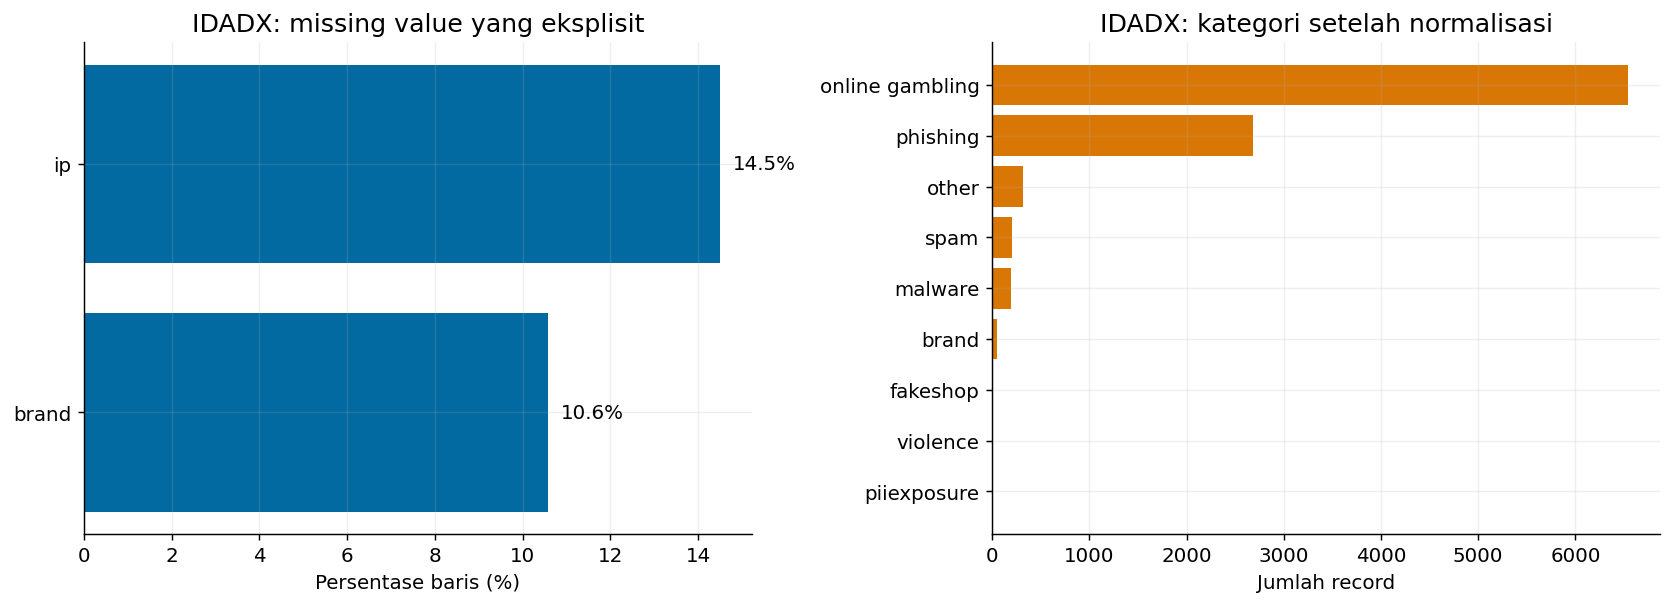

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

missing_idadx = idadx_raw.isna().mean().mul(100)
missing_idadx = missing_idadx[missing_idadx.gt(0)].sort_values()
axes[0].barh(missing_idadx.index, missing_idadx.values, color=COLORS["blue"])
axes[0].set_title("IDADX: missing value yang eksplisit")
axes[0].set_xlabel("Persentase baris (%)")
for i, value in enumerate(missing_idadx.values):
    axes[0].text(value + 0.3, i, f"{value:.1f}%", va="center")

category_counts = idadx["category_clean"].value_counts().sort_values()
axes[1].barh(category_counts.index, category_counts.values, color=COLORS["gold"])
axes[1].set_title("IDADX: kategori setelah normalisasi")
axes[1].set_xlabel("Jumlah record")

plt.tight_layout()
plt.show()

### Duplikasi: ada lebih dari satu definisi

Tiga pertanyaan yang berbeda akan menghasilkan angka yang berbeda:

1. Apakah seluruh nilai pada satu baris sama persis?
2. Apakah URL yang sama muncul kembali?
3. Apakah domain yang sama muncul pada banyak observasi?

Pada data yang dimasking, dua domain berbeda juga dapat tampak sama karena panjang teks mask-nya sama. Jadi **duplicate setelah masking belum tentu duplicate pada data asli**.

In [8]:
duplicate_summary = pd.Series({
    "Baris identik penuh": idadx_raw.duplicated().sum(),
    "Kemunculan URL setelah yang pertama": idadx_raw.duplicated(subset="url").sum(),
    "Kemunculan domain setelah yang pertama": idadx_raw.duplicated(subset="domain").sum(),
    "URL unik (setelah masking)": idadx_raw["url"].nunique(),
    "Domain unik (setelah masking)": idadx_raw["domain"].nunique(),
}, name="jumlah").astype(int)

display(duplicate_summary.to_frame())

domain_group_size = idadx_raw.groupby("domain").size()
display(domain_group_size.describe().rename("record_per_domain").to_frame())

,jumlah
Baris identik penuh,32
Kemunculan URL setelah yang pertama,699
Kemunculan domain setelah yang pertama,9809
URL unik (setelah masking),9301
Domain unik (setelah masking),191


,record_per_domain
count,191.00
mean,52.36
std,116.00
min,1.00
25%,2.00
50%,9.00
75%,41.50
max,"1,000.00"


<details>
<summary><b>Diskusi: apakah 32 baris identik harus langsung dihapus?</b></summary>

Belum tentu. Kita perlu mengetahui:

- apakah duplikasi berasal dari pengumpulan berulang;
- apakah setiap baris mewakili laporan dari sumber berbeda;
- apakah timestamp presisinya hilang atau disederhanakan;
- apakah masking membuat record berbeda menjadi identik.

**Tindakan aman:** tandai, dokumentasikan, lalu konfirmasi grain dan aturan deduplikasi sebelum menghapus.
</details>

### Audit temporal — apakah urutan waktunya masuk akal?

Jika `registration_date` adalah tanggal domain didaftarkan dan `discovered` adalah tanggal penyalahgunaan ditemukan, secara intuitif registrasi seharusnya tidak terjadi setelah penemuan. Mari uji, tetapi jangan langsung menuduh data salah.

In [9]:
idadx["discovered_dt"] = pd.to_datetime(idadx["discovered"], errors="coerce")
idadx["registration_dt"] = pd.to_datetime(idadx["registration_date"], errors="coerce")

future_registration = idadx["registration_dt"] > idadx["discovered_dt"]

temporal_check = pd.Series({
    "Tanggal discovered gagal diparse": idadx["discovered_dt"].isna().sum(),
    "Tanggal registration gagal diparse": idadx["registration_dt"].isna().sum(),
    "Registration lebih akhir dari discovered": future_registration.sum(),
    "Persentase anomali urutan waktu": future_registration.mean() * 100,
}, name="nilai")

display(temporal_check.to_frame())
print("Rentang discovered :", idadx["discovered_dt"].min(), "s.d.", idadx["discovered_dt"].max())
print("Rentang registration:", idadx["registration_dt"].min(), "s.d.", idadx["registration_dt"].max())

Rentang discovered : 2020-01-08 07:31:33 s.d. 2024-08-06 11:33:19.099000
Rentang registration: 1995-01-01 00:00:00 s.d. 2026-08-21 00:00:00


,nilai
Tanggal discovered gagal diparse,0.00
Tanggal registration gagal diparse,0.00
Registration lebih akhir dari discovered,"2,563.00"
Persentase anomali urutan waktu,25.63


<details>
<summary><b>Mengapa anomali waktu ini dapat terjadi?</b></summary>

Beberapa hipotesis yang layak diuji:

- tanggal registrasi diperbarui dari snapshot yang lebih baru;
- domain didaftarkan ulang, tetapi kolom menyimpan tanggal registrasi terakhir;
- record digabung dari sistem dengan definisi waktu berbeda;
- relasi domain/record berubah selama proses masking;
- terdapat kesalahan sumber atau transformasi.

Kita belum memiliki bukti untuk memilih salah satunya. Temuan yang benar adalah: **2.563 record perlu ditelusuri karena urutan waktunya tidak sesuai interpretasi awal kita.**
</details>

## 5. EDA sebagai investigasi — IDADX

**EDA bukan kompetisi membuat grafik yang indah.** Setiap visual harus menjawab pertanyaan.

Pertanyaan investigasi kita:

1. Kategori apa yang dominan?
2. Kapan record paling banyak ditemukan?
3. Apakah record terkonsentrasi pada kelompok SLD tertentu?
4. Berapa banyak record yang dapat muncul untuk representasi domain yang sama?

Perhatikan pula ketegangan antara **nama file** yang mengandung kata `phishes` dan **komposisi kategori aktual**. Nama file adalah petunjuk administratif, bukan definisi populasi yang boleh dipercaya tanpa pemeriksaan.

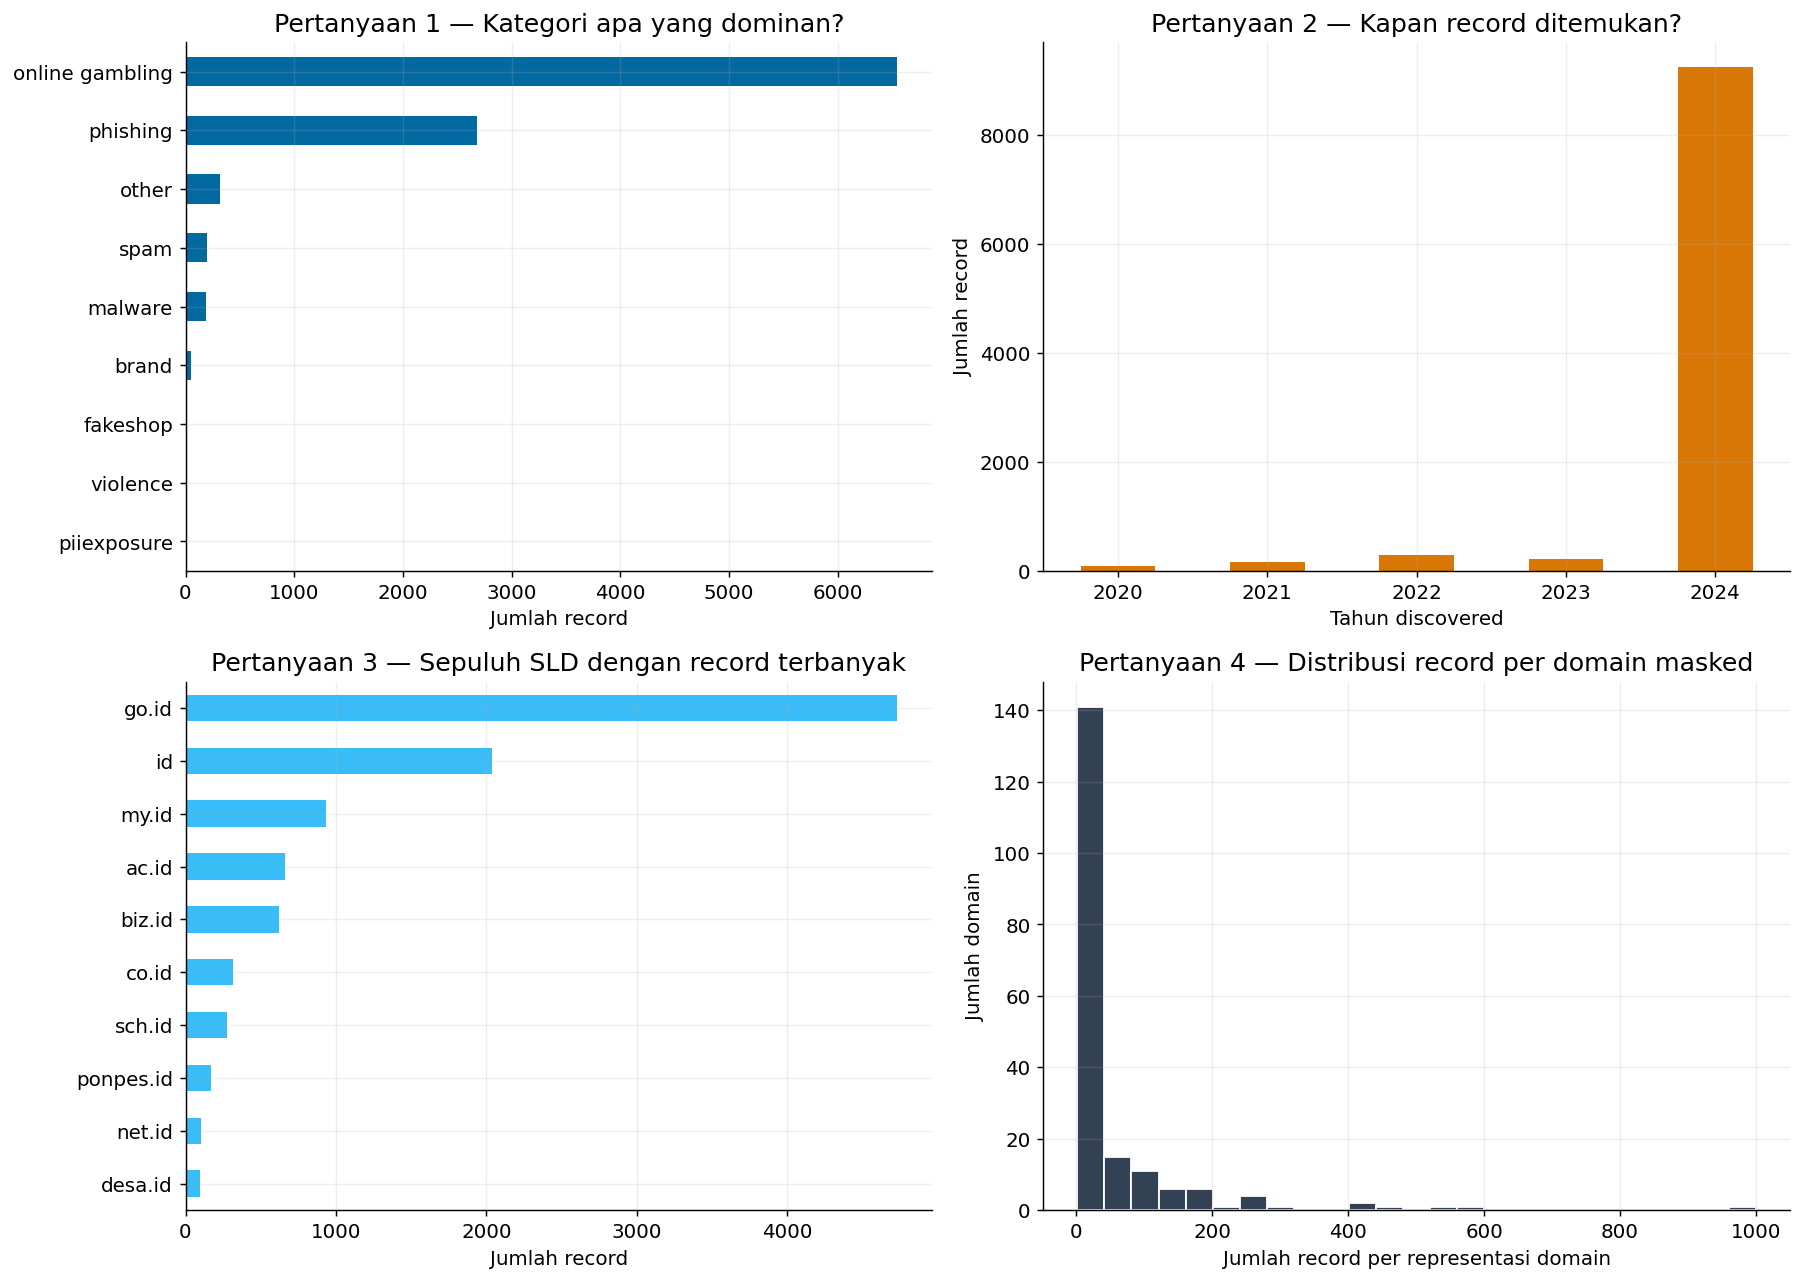

In [10]:
idadx["discovered_year"] = idadx["discovered_dt"].dt.year
idadx["discovered_month"] = idadx["discovered_dt"].dt.to_period("M").astype(str)

category_counts = idadx["category_clean"].value_counts()
sld_counts = idadx["sld"].value_counts().head(10)
year_counts = idadx["discovered_year"].value_counts().sort_index()
domain_sizes = idadx.groupby("domain").size()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

category_counts.sort_values().plot.barh(ax=axes[0, 0], color=COLORS["blue"])
axes[0, 0].set_title("Pertanyaan 1 — Kategori apa yang dominan?")
axes[0, 0].set_xlabel("Jumlah record")
axes[0, 0].set_ylabel("")

year_counts.plot.bar(ax=axes[0, 1], color=COLORS["gold"], rot=0)
axes[0, 1].set_title("Pertanyaan 2 — Kapan record ditemukan?")
axes[0, 1].set_xlabel("Tahun discovered")
axes[0, 1].set_ylabel("Jumlah record")

sld_counts.sort_values().plot.barh(ax=axes[1, 0], color=COLORS["sky"])
axes[1, 0].set_title("Pertanyaan 3 — Sepuluh SLD dengan record terbanyak")
axes[1, 0].set_xlabel("Jumlah record")
axes[1, 0].set_ylabel("")

axes[1, 1].hist(domain_sizes, bins=25, color=COLORS["slate"], edgecolor="white")
axes[1, 1].set_title("Pertanyaan 4 — Distribusi record per domain masked")
axes[1, 1].set_xlabel("Jumlah record per representasi domain")
axes[1, 1].set_ylabel("Jumlah domain")

plt.tight_layout()
plt.show()

In [11]:
# Ringkasan yang mendukung pembacaan grafik, bukan menggantikannya.
idadx_facts = pd.Series({
    "Record kategori terbesar": int(category_counts.iloc[0]),
    "Porsi kategori terbesar (%)": float(category_counts.iloc[0] / len(idadx) * 100),
    "Representasi domain unik": int(idadx["domain"].nunique()),
    "Median record per domain": float(domain_sizes.median()),
    "Maksimum record pada satu domain masked": int(domain_sizes.max()),
    "Confidence level = 100 (%)": float(idadx["confidence_level"].eq(100).mean() * 100),
}, name="nilai")

display(idadx_facts.to_frame())

,nilai
Record kategori terbesar,"6,543.00"
Porsi kategori terbesar (%),65.43
Representasi domain unik,191.00
Median record per domain,9.00
Maksimum record pada satu domain masked,"1,000.00"
Confidence level = 100 (%),97.07


### Aktivitas 2 — Observasi, interpretasi, atau pertanyaan?

Klasifikasikan setiap kalimat:

1. “Kategori terbesar mencakup lebih dari separuh record.”
2. “Kategori terbesar adalah ancaman paling berbahaya.”
3. “Sebagian besar record ditemukan pada 2024.”
4. “Peningkatan 2024 membuktikan serangan meningkat.”
5. “Apakah cakupan/sumber pengumpulan berubah pada 2024?”

<details>
<summary><b>Klik untuk pembahasan</b></summary>

- (1) dan (3): **observasi deskriptif**, selama angkanya benar.
- (2) dan (4): **interpretasi yang belum didukung**. Frekuensi bukan otomatis tingkat bahaya; kenaikan record dapat dipengaruhi perubahan coverage.
- (5): **pertanyaan investigasi** yang tepat untuk pemilik data.
</details>

## 6. Data berbeda, cara berpikir sama — DNS

Sekarang kita berpindah dari record laporan/observasi penyalahgunaan ke event protokol jaringan.

Pertanyaan kunci:

- Apakah baris merupakan query atau response?
- Bagaimana memasangkan keduanya?
- Apakah kapitalisasi pada `qname` bermakna?
- Apakah label “30min” pada nama file sama dengan rentang timestamp yang terlihat?

In [12]:
# Normalisasi sesuai karakter DNS: nama tidak peka huruf besar/kecil.
dns["ts_dt"] = pd.to_datetime(dns["ts_iso"], utc=True, errors="coerce")
dns["message_type"] = dns["qr"].map({0: "Query", 1: "Response"}).fillna("Unknown")
dns["qname_normalized"] = (
    dns["qname"].astype("string").str.strip().str.rstrip(".").str.lower()
)
dns["rcode_name"] = dns["rcode"].map({0: "NOERROR", 3: "NXDOMAIN"}).fillna("OTHER")

normalization_check = pd.Series({
    "qname unik sebelum normalisasi": dns["qname"].nunique(),
    "qname unik setelah normalisasi": dns["qname_normalized"].nunique(),
    "selisih": dns["qname"].nunique() - dns["qname_normalized"].nunique(),
}, name="jumlah")
display(normalization_check.to_frame())

case_variants = (
    dns.groupby("qname_normalized")["qname"]
       .nunique()
       .sort_values(ascending=False)
       .head(8)
       .rename("jumlah_variasi_penulisan")
)
display(case_variants.to_frame())

,jumlah
qname unik sebelum normalisasi,49
qname unik setelah normalisasi,38
selisih,11


,jumlah_variasi_penulisan
qname_normalized,
smartconnect.id,7
axarva.id,3
speedtest.rndlabbankmandiri.co.id,3
koalaapp.id,2
_autodiscover._tcp.tppi.co.id,1
67130034.id,1
ashkjghkj154289.co.id,1
api.pt-gama.co.id,1


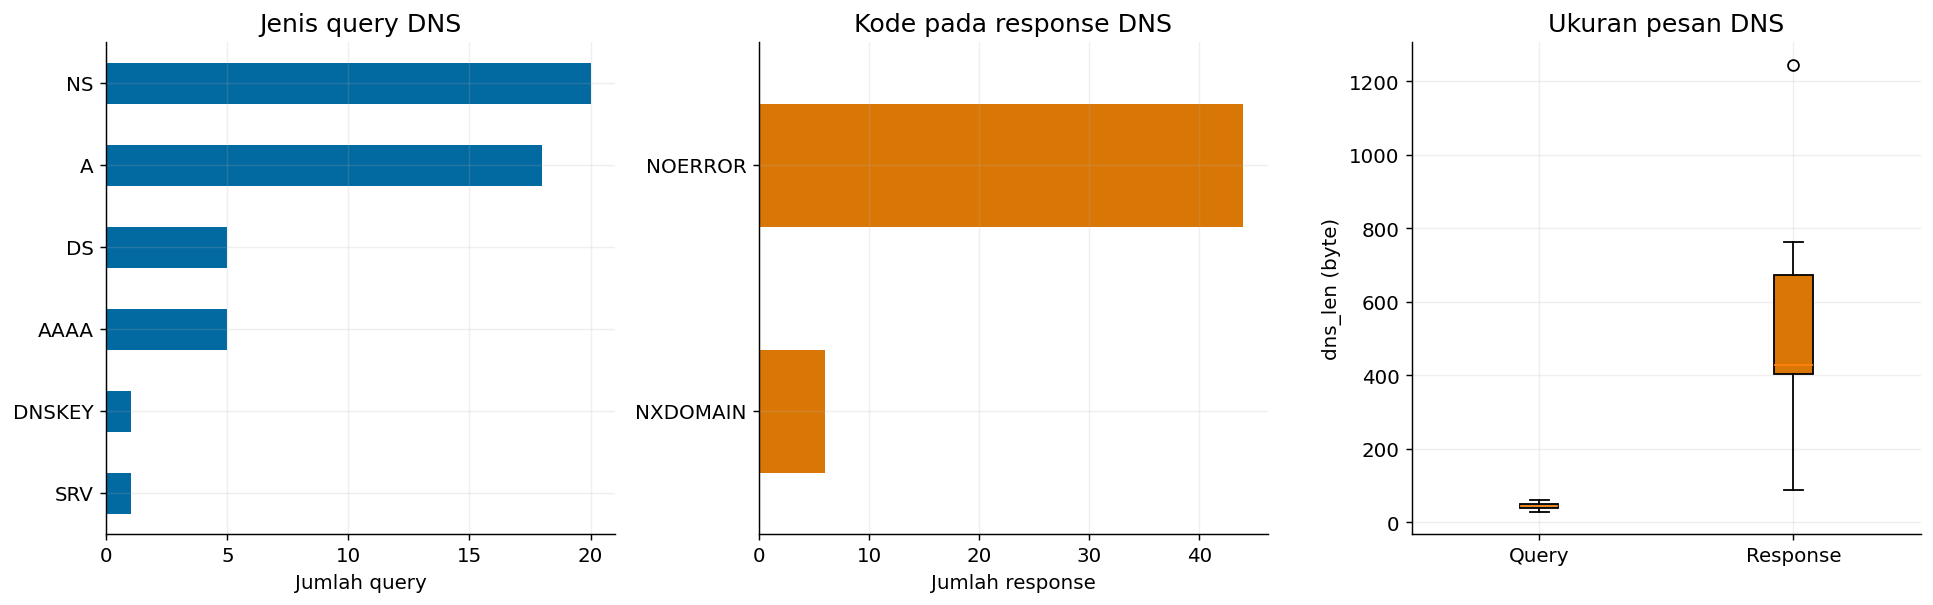

In [13]:
queries = dns[dns["qr"].eq(0)].copy()
responses = dns[dns["qr"].eq(1)].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

queries["qtype_name"].value_counts().sort_values().plot.barh(
    ax=axes[0], color=COLORS["blue"]
)
axes[0].set_title("Jenis query DNS")
axes[0].set_xlabel("Jumlah query")
axes[0].set_ylabel("")

responses["rcode_name"].value_counts().sort_values().plot.barh(
    ax=axes[1], color=COLORS["gold"]
)
axes[1].set_title("Kode pada response DNS")
axes[1].set_xlabel("Jumlah response")
axes[1].set_ylabel("")

size_data = [queries["dns_len"], responses["dns_len"]]
box = axes[2].boxplot(size_data, tick_labels=["Query", "Response"], patch_artist=True)
box["boxes"][0].set_facecolor(COLORS["sky"])
box["boxes"][1].set_facecolor(COLORS["gold"])
axes[2].set_title("Ukuran pesan DNS")
axes[2].set_ylabel("dns_len (byte)")

plt.tight_layout()
plt.show()

### Memeriksa transaksi query–response

`dns_id` dapat membantu memasangkan record, tetapi pada data jaringan yang lebih besar ia belum tentu unik secara global. Kombinasi waktu, endpoint, port, protokol, ID, qname, dan qtype mungkin diperlukan.

Untuk sampel kecil ini, kita periksa apakah setiap `dns_id` muncul dua kali dan memiliki kedua nilai `qr`.

,jumlah
Jumlah dns_id,50
Pasangan lengkap menurut aturan sederhana,50
Pasangan yang perlu diperiksa,0


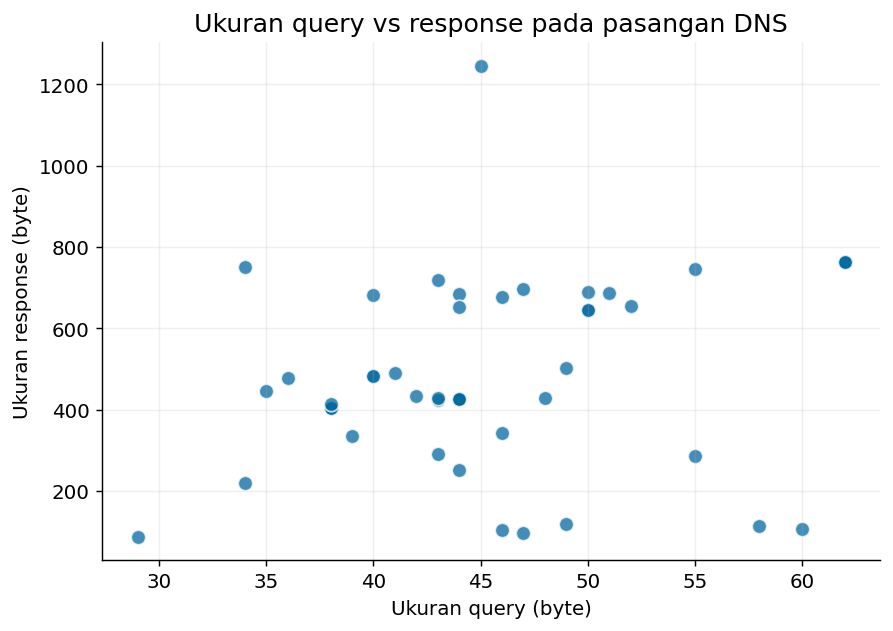

In [14]:
pair_audit = (
    dns.groupby("dns_id")
       .agg(
           jumlah_baris=("dns_id", "size"),
           variasi_qr=("qr", "nunique"),
           variasi_qname=("qname_normalized", "nunique"),
           variasi_qtype=("qtype", "nunique"),
       )
)

valid_pair = (
    pair_audit["jumlah_baris"].eq(2)
    & pair_audit["variasi_qr"].eq(2)
    & pair_audit["variasi_qname"].eq(1)
    & pair_audit["variasi_qtype"].eq(1)
)

pair_summary = pd.Series({
    "Jumlah dns_id": len(pair_audit),
    "Pasangan lengkap menurut aturan sederhana": valid_pair.sum(),
    "Pasangan yang perlu diperiksa": (~valid_pair).sum(),
}, name="jumlah").astype(int)
display(pair_summary.to_frame())

paired_size = (
    dns.pivot_table(index="dns_id", columns="message_type", values="dns_len", aggfunc="first")
       .dropna(subset=["Query", "Response"])
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(paired_size["Query"], paired_size["Response"], alpha=0.75,
           color=COLORS["blue"], edgecolor="white", s=65)
ax.set_title("Ukuran query vs response pada pasangan DNS")
ax.set_xlabel("Ukuran query (byte)")
ax.set_ylabel("Ukuran response (byte)")
plt.tight_layout()
plt.show()

### Sanity check waktu

Nama file mengandung “30min”, tetapi apakah baris sampel yang kita terima benar-benar tersebar selama 30 menit?

In [15]:
observed_span = dns["ts_dt"].max() - dns["ts_dt"].min()

time_summary = pd.Series({
    "Timestamp paling awal": dns["ts_dt"].min(),
    "Timestamp paling akhir": dns["ts_dt"].max(),
    "Rentang timestamp pada 100 baris": observed_span,
    "Jumlah query": int(dns["qr"].eq(0).sum()),
    "Jumlah response": int(dns["qr"].eq(1).sum()),
}, name="nilai")
display(time_summary.to_frame())

,nilai
Timestamp paling awal,2026-08-19 07:49:57.649752+00:00
Timestamp paling akhir,2026-08-19 07:49:57.671122+00:00
Rentang timestamp pada 100 baris,0 days 00:00:00.021370
Jumlah query,50
Jumlah response,50


<details>
<summary><b>Apa kesimpulan yang aman?</b></summary>

Baris yang tersedia hanya mencakup sekitar **21 milidetik**, walaupun nama file menyebut “30min”. Kesimpulan yang aman bukan “nama file salah”, melainkan:

> Sampel 100 baris ini kemungkinan diambil dari capture/jendela yang lebih besar, tetapi tidak merepresentasikan sebaran waktu 30 menit secara langsung.

Konsekuensinya, kita **tidak boleh** menghitung laju query per 30 menit dari 100 baris ini tanpa memahami metode sampling.
</details>

### Aktivitas 3 — Pilih denominator yang benar

Apakah kita dapat menyatakan salah satu kalimat berikut?

1. “Terdapat 50 query DNS selama 30 menit.”
2. “Dalam sampel 100 record, terdapat 50 query dan 50 response.”
3. “Sebanyak 12% response menghasilkan NXDOMAIN.”
4. “Sebanyak 6% seluruh record menghasilkan NXDOMAIN.”

<details>
<summary><b>Klik untuk pembahasan</b></summary>

- (1) **tidak aman**, karena sampel baris tidak terbukti mencakup 30 menit.
- (2) **aman**, karena denominator dan cakupan dinyatakan eksplisit.
- (3) **aman untuk sampel ini**: 6 dari 50 response.
- (4) secara aritmetika 6 dari 100, tetapi istilah “menghasilkan” kurang tepat karena query dan response dicampur. Denominator response lebih bermakna untuk `rcode`.
</details>

## 7. Jebakan pertama — Data leakage

> **Available in the dataset ≠ available at prediction time.**

Data leakage muncul ketika model memakai informasi yang tidak seharusnya tersedia saat prediksi dilakukan. Sebelum menilai kolom, kita harus mendefinisikan skenario.

**Skenario diskusi:** Kita ingin memprioritaskan laporan baru yang memerlukan penanganan. Prediksi dilakukan saat laporan pertama kali masuk.

Untuk setiap kolom, tanyakan:

1. Apakah tersedia saat laporan masuk?
2. Apakah muncul setelah proses penanganan?
3. Apakah sebenarnya target/outcome?
4. Apakah hanya identifier atau metadata?
5. Apakah definisinya stabil di train dan data masa depan?

In [16]:
# Worksheet diskusi. Isi kolom 'dugaan_peran' dan 'alasan' bersama peserta.
leakage_candidates = pd.DataFrame({
    "kolom": [
        "url", "brand", "discovered", "confidence_level", "ip", "domain",
        "sld", "category", "registrar", "registration_date",
        "handle", "resolved", "handle_status", "resolved_status"
    ],
    "dugaan_peran": ["diskusikan"] * 14,
    "tersedia_saat_prediksi": ["belum diketahui"] * 14,
    "alasan / pertanyaan ke pemilik data": [""] * 14,
})

display(leakage_candidates)

,kolom,dugaan_peran,tersedia_saat_prediksi,alasan / pertanyaan ke pemilik data
0,url,diskusikan,belum diketahui,
1,brand,diskusikan,belum diketahui,
2,discovered,diskusikan,belum diketahui,
3,confidence_level,diskusikan,belum diketahui,
4,ip,diskusikan,belum diketahui,
5,domain,diskusikan,belum diketahui,
6,sld,diskusikan,belum diketahui,
7,category,diskusikan,belum diketahui,
8,registrar,diskusikan,belum diketahui,
9,registration_date,diskusikan,belum diketahui,


<details>
<summary><b>Catatan fasilitator — arah pembahasan leakage</b></summary>

Tidak ada klasifikasi final tanpa definisi target dan proses bisnis. Namun:

- `handle_status` dan `resolved_status` patut dicurigai sebagai outcome atau informasi pascaproses;
- `category` dapat menjadi target pada skenario klasifikasi kategori, tetapi predictor pada skenario lain;
- `confidence_level` dapat merupakan hasil dari sistem verifikasi, sehingga waktu pembentukannya penting;
- `url`, `domain`, dan `ip` dapat bertindak sebagai identifier yang mudah dihafal model;
- `discovered` dapat membawa pola waktu dan perubahan proses pengumpulan;
- `registrar` tidak boleh ditafsirkan sebagai penyebab hanya karena berkorelasi dengan jumlah record.

**Kesimpulan:** status sebuah kolom tidak melekat secara permanen. Ia bergantung pada target, waktu prediksi, dan alur operasional.
</details>

## 8. Mini-challenge — Apakah data ini siap untuk modeling? (10 menit)

Dalam kelompok kecil, temukan **tiga hal** yang membuat Anda ragu untuk langsung membangun model. Untuk setiap hal, isi:

| Temuan | Bukti kuantitatif | Mengapa penting? | Tindakan berikutnya |
|---|---:|---|---|
| Contoh: kategori tidak konsisten | Bandingkan jumlah kategori sebelum/sesudah normalisasi | Kelas yang sama dapat terpecah | Dokumentasikan aturan standardisasi |
| 1. ... | ... | ... | ... |
| 2. ... | ... | ... | ... |
| 3. ... | ... | ... | ... |

Gunakan checklist berikut sebagai bantuan:

- [ ] grain/unit observasi sudah jelas;
- [ ] target dan waktu prediksi sudah didefinisikan;
- [ ] missing value dan kode khusus sudah dipahami;
- [ ] kategori sudah konsisten;
- [ ] duplikasi telah dinilai sesuai grain dan dampak masking;
- [ ] urutan waktu telah diuji;
- [ ] sampling dan coverage telah dipahami;
- [ ] kandidat leakage telah ditandai;
- [ ] denominator setiap metrik sudah tepat.

In [17]:
# Template catatan kelompok — dapat diisi langsung di notebook.
mini_challenge = pd.DataFrame({
    "temuan": ["", "", ""],
    "bukti_kuantitatif": ["", "", ""],
    "mengapa_penting": ["", "", ""],
    "tindakan_berikutnya": ["", "", ""],
}, index=[1, 2, 3])

display(mini_challenge)

,temuan,bukti_kuantitatif,mengapa_penting,tindakan_berikutnya
1,,,,
2,,,,
3,,,,


## 9. Ringkasan otomatis dari data yang sedang dimuat

Sel berikut menghasilkan ringkasan berbasis output aktual. Jika file berubah, angka pada ringkasan juga ikut berubah.

In [18]:
top_category = idadx["category_clean"].value_counts().index[0]
top_category_n = int(idadx["category_clean"].value_counts().iloc[0])
n_future = int((idadx["registration_dt"] > idadx["discovered_dt"]).sum())
n_valid_pairs = int(valid_pair.sum())
n_nxdomain = int(responses["rcode"].eq(3).sum())

display(Markdown(f'''
### Temuan utama sesi

- IDADX berisi **{len(idadx):,} record** dan **{idadx_raw.shape[1]} kolom asli**; setelah normalisasi, kategori terbesar adalah **{top_category}** dengan **{top_category_n:,} record**.
- Kolom `brand` memiliki **{idadx_raw['brand'].isna().sum():,}** missing eksplisit, tetapi menjadi **{idadx['brand_clean'].isna().sum():,}** setelah simbol `-` diperlakukan sebagai *semantic missing*.
- Terdapat **{idadx_raw.duplicated().sum():,}** baris identik dan **{idadx_raw.duplicated('url').sum():,}** kemunculan URL setelah yang pertama; dampak masking membuat angka ini tidak boleh langsung dianggap duplikasi pada data asli.
- Sebanyak **{n_future:,} record** memiliki `registration_date` yang lebih akhir daripada `discovered`; penyebabnya masih perlu dikonfirmasi.
- Sampel DNS membentuk **{n_valid_pairs} pasangan query–response lengkap** menurut aturan sederhana berbasis `dns_id`.
- Pada **{len(responses)} response**, terdapat **{n_nxdomain} NXDOMAIN**; rentang timestamp 100 baris hanya **{observed_span.total_seconds():.6f} detik**.

> Semua poin di atas adalah **temuan deskriptif dari sampel**, bukan kesimpulan kausal atau penilaian terhadap pihak tertentu.
'''))


### Temuan utama sesi

- IDADX berisi **10,000 record** dan **14 kolom asli**; setelah normalisasi, kategori terbesar adalah **online gambling** dengan **6,543 record**.
- Kolom `brand` memiliki **1,058** missing eksplisit, tetapi menjadi **5,970** setelah simbol `-` diperlakukan sebagai *semantic missing*.
- Terdapat **32** baris identik dan **699** kemunculan URL setelah yang pertama; dampak masking membuat angka ini tidak boleh langsung dianggap duplikasi pada data asli.
- Sebanyak **2,563 record** memiliki `registration_date` yang lebih akhir daripada `discovered`; penyebabnya masih perlu dikonfirmasi.
- Sampel DNS membentuk **50 pasangan query–response lengkap** menurut aturan sederhana berbasis `dns_id`.
- Pada **50 response**, terdapat **6 NXDOMAIN**; rentang timestamp 100 baris hanya **0.021370 detik**.

> Semua poin di atas adalah **temuan deskriptif dari sampel**, bukan kesimpulan kausal atau penilaian terhadap pihak tertentu.


## 10. Penutup — Tiga aturan yang dibawa pulang

1. **Jangan percaya nama kolom tanpa memahami proses yang membentuknya.**
2. **Jangan percaya grafik tanpa grain, denominator, coverage, dan konteks waktu.**
3. **Jangan percaya skor model sebelum memastikan tidak ada leakage atau pengulangan entitas.**

> **Rule #1 of Data Science:** Never trust a dataset you have not interrogated.

### Jembatan ke sesi berikutnya

Besok kita akan membuat “kesalahan berikutnya”: mempercayai model hanya karena akurasinya tinggi.

**Sesi II — Build a Model That Generalizes** akan membahas:

- definisi `X` dan `y`;
- baseline dan pipeline;
- train/validation/test;
- precision, recall, dan $F_1$ untuk konteks keamanan;
- cross-validation;
- group leakage ketika domain yang sama muncul di train dan test.

---

### Pertanyaan refleksi terakhir

> Jika dataset ini diberikan untuk lomba hari ini, **informasi apa yang akan Anda tanyakan terlebih dahulu kepada PANDI sebelum modeling?**